<a href="https://colab.research.google.com/github/srs3161/Hands-On-Ai-and-Robotics/blob/main/Copy_of_Course_Project_6_Reinforcement_Learning_Policy_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Course Project 6 - Reinforcement Learning**
* In this project, you will learn to train an actor using policy gradient to control a rocket landing on a rough surface.
* This project was adapted from Dr. Hung-Yi Lee's Machine Learning course (Spring 2022). Source: https://speech.ee.ntu.edu.tw/~hylee/ml/2022-spring.php


## Preliminary work

First, we need to install all necessary packages.
One of them, gym, builded by OpenAI, is a toolkit for developing Reinforcement Learning algorithm. Other packages are for visualization in colab.

In [20]:
# @title Update/Upgrade the system and install libs
!apt-get update > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!apt-get install -y swig build-essential python-dev python3-dev > /dev/null 2>&1
!apt-get install x11-utils > /dev/null 2>&1
!apt-get install xvfb > /dev/null 2>&1

# @title Install dependencies
!pip install rarfile --quiet
!pip install ale-py --quiet
!pip install swig
!pip install gym --quiet
!pip install pyvirtualdisplay --quiet
!pip install pyglet --quiet
!pip install pygame --quiet
!pip install minigrid --quiet
!pip install -q swig --quiet
!pip install -q gymnasium --quiet
!pip install 'minigrid<=2.1.1' --quiet
!pip3 install box2d-py --quiet


Next, set up virtual display，and import all necessaary packages.

In [21]:
%%capture
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

%matplotlib inline
import matplotlib.pyplot as plt

from IPython import display

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from tqdm.notebook import tqdm

# Fix the environment
Make your result to be reproducible. Don't change this.


In [22]:
seed = 2026
def fix(env, seed):
  # env.seed(seed) # Remove this line
  # env.action_space.seed(seed) # Remove this line
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
      torch.cuda.manual_seed_all(seed)

Last, call gym and build an [Lunar Lander](https://gym.openai.com/envs/LunarLander-v2/) environment.

In [23]:
%%capture
import gymnasium as gym
import random
env = gym.make('LunarLander-v3', render_mode='rgb_array')
fix(env, seed) # fix the environment

## What Lunar Lander？

“LunarLander-v2”is to simulate the situation when the craft lands on the surface of the moon.

This task is to enable the craft to land "safely" at the pad between the two yellow flags.
> Landing pad is always at coordinates (0,0).
> Coordinates are the first two numbers in state vector.

![](https://gym.openai.com/assets/docs/aeloop-138c89d44114492fd02822303e6b4b07213010bb14ca5856d2d49d6b62d88e53.svg)

"LunarLander-v2" actually includes "Agent" and "Environment".

In this homework, we will utilize the function `step()` to control the action of "Agent".

Then `step()` will return the observation/state and reward given by the "Environment".

### Observation / State

First, we can take a look at what an Observation / State looks like.

In [24]:
print(env.observation_space)

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)



`Box(8,)`means that observation is an 8-dim vector
### Action

Actions can be taken by looks like

In [25]:
print(env.action_space)

Discrete(4)


`Discrete(4)` implies that there are four kinds of actions can be taken by agent.
- 0 implies the agent will not take any actions
- 2 implies the agent will accelerate downward
- 1, 3 implies the agent will accelerate left and right

Next, we will try to make the agent interact with the environment.
Before taking any actions, we recommend to call `reset()` function to reset the environment. Also, this function will return the initial state of the environment.

In [26]:
initial_state = env.reset()
print(initial_state)

(array([-8.1863406e-04,  1.4121089e+00, -8.2945660e-02,  5.2835487e-02,
        9.5549203e-04,  1.8788446e-02,  0.0000000e+00,  0.0000000e+00],
      dtype=float32), {})


Then, we try to get a random action from the agent's action space.

In [27]:
random_action = env.action_space.sample()
print(random_action)

3


More, we can utilize `step()` to make agent act according to the randomly-selected `random_action`.
The `step()` function will return four values:
- observation / state
- reward
- done (True/ False)
- Other information

In [28]:
initial_state, info = env.reset() # Add env.reset() here
observation, reward, terminated, truncated, info = env.step(random_action)
done = terminated or truncated

In [29]:
print(observation)

[ 0.01056652  1.4266717   0.5395961   0.33701345 -0.01377497 -0.15401644
  0.          0.        ]


### Reward


> Landing pad is always at coordinates (0,0). Coordinates are the first two numbers in state vector. Reward for moving from the top of the screen to landing pad and zero speed is about 100..140 points. If lander moves away from landing pad it loses reward back. Episode finishes if the lander crashes or comes to rest, receiving additional -100 or +100 points. Each leg ground contact is +10. Firing main engine is -0.3 points each frame. Solved is 200 points.

In [30]:
print(reward)

-0.8103568160794328


### Random Agent
In the end, before we start training, we can see whether a random agent can successfully land the moon or not.

In [31]:
import os
from gymnasium.wrappers import RecordVideo

# Create a directory to save the videos
video_dir = "./videos"
os.makedirs(video_dir, exist_ok=True)

# Wrap the environment with RecordVideo
env = RecordVideo(env, video_dir)

env.reset()

done = False
while not done:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

# Close the environment to save the video
env.close()

# Rename the video file
import glob
list_of_files = glob.glob(f'{video_dir}/*.mp4')
latest_file = max(list_of_files, key=os.path.getctime)
new_file_name = os.path.join(video_dir, "random_agent.mp4")
os.rename(latest_file, new_file_name)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Play the video

In [32]:
import io
import base64
from IPython.display import HTML, display # Import display explicitly

video_path = "./videos/random_agent.mp4" # Assuming the video is named random_agent.mp4

try:
    with io.open(video_path, 'r+b') as f:
        encoded = base64.b64encode(f.read()).decode()
    uploaded = HTML(data='''
        <video width="320" height="240" controls>
            <source src="data:video/mp4;base64,{}" type="video/mp4" />
        </video>'''.format(encoded))
    display(uploaded)
except FileNotFoundError:
    print(f"Video file not found at {video_path}")

## Policy Gradient
Now, we can build a simple policy network. The network will return one of action in the action space.

In [33]:
class PolicyGradientNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(8, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        self.actor = nn.Linear(256, 4)
        self.critic = nn.Linear(256, 1)

    def forward(self, state):
        x = self.shared(state)
        logits = self.actor(x)
        value = self.critic(x)
        return logits, value

Then, we need to build a simple agent. The agent will acts according to the output of the policy network above. There are a few things can be done by agent:
- `learn()`：update the policy network from log probabilities and rewards.
- `sample()`：After receiving observation from the environment, utilize policy network to tell which action to take. The return values of this function includes action and log probabilities.

In [34]:
class PolicyGradientAgent():
    def __init__(self, network):
        self.network = network
        self.optimizer = optim.Adam(self.network.parameters(), lr=0.0007)

    def sample(self, state):
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        logits, value = self.network(state)
        dist = Categorical(logits=logits)

        action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()

        return log_prob.squeeze(), action.item(), value.squeeze(), entropy.squeeze()

    def learn(self, log_probs, returns, values, entropies):
        log_probs = torch.stack(log_probs)
        values = torch.stack(values)
        entropies = torch.stack(entropies)

        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        advantages = returns - values.detach()

        actor_loss = -(log_probs * advantages).sum()
        critic_loss = F.mse_loss(values, returns)
        entropy_loss = -entropies.sum()

        loss = actor_loss + 0.5 * critic_loss + 0.01 * entropy_loss

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
        self.optimizer.step()

## Training Agent

Now let's start to train our agent.
Through taking all the interactions between agent and environment as training data, the policy network can learn from all these attempts,

In [35]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return torch.tensor(returns, dtype=torch.float32)

# --- Main training loop ---
env = gym.make("LunarLander-v3")
network = PolicyGradientNetwork()
agent = PolicyGradientAgent(network)

num_episodes = 1200
gamma = 0.99
reward_history = []

print("Training Start")

for episode in range(1, num_episodes + 1):
    state, _ = env.reset()
    log_probs = []
    values = []
    entropies = []
    rewards = []
    total_reward = 0
    done = False

    while not done:
        log_prob, action, value, entropy = agent.sample(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        # record transitions for learning
        log_probs.append(log_prob)
        values.append(value)
        entropies.append(entropy)
        rewards.append(reward)
        total_reward += reward
        state = next_state

        if done or truncated:
            break

    returns = compute_returns(rewards, gamma)
    #log_probs = torch.stack(log_probs)
    agent.learn(log_probs, returns, values, entropies)

    reward_history.append(total_reward)

    if episode % 100 == 0:
        avg_reward = np.mean(reward_history[-10:])
        print(f"Episode {episode}, Avg Reward: {avg_reward:.2f}, Reward from Last Episode: {total_reward:.2f}")

env.close()


Training Start
Episode 100, Avg Reward: -276.35, Reward from Last Episode: -184.62
Episode 200, Avg Reward: -78.03, Reward from Last Episode: -76.83
Episode 300, Avg Reward: 2.60, Reward from Last Episode: 26.87
Episode 400, Avg Reward: 5.77, Reward from Last Episode: 86.73
Episode 500, Avg Reward: -52.39, Reward from Last Episode: 49.56
Episode 600, Avg Reward: 99.63, Reward from Last Episode: 133.35
Episode 700, Avg Reward: 106.54, Reward from Last Episode: 121.99
Episode 800, Avg Reward: 129.54, Reward from Last Episode: 169.69
Episode 900, Avg Reward: 91.75, Reward from Last Episode: 112.94
Episode 1000, Avg Reward: 96.63, Reward from Last Episode: 139.22
Episode 1100, Avg Reward: 136.90, Reward from Last Episode: 102.80
Episode 1200, Avg Reward: 78.08, Reward from Last Episode: 74.53


### Training Result
During the training process, we recorded `avg_total_reward`, which represents the average total reward of episodes before updating the policy network.

Theoretically, if the agent becomes better, the `avg_total_reward` will increase.
The visualization of the training process is shown below:  


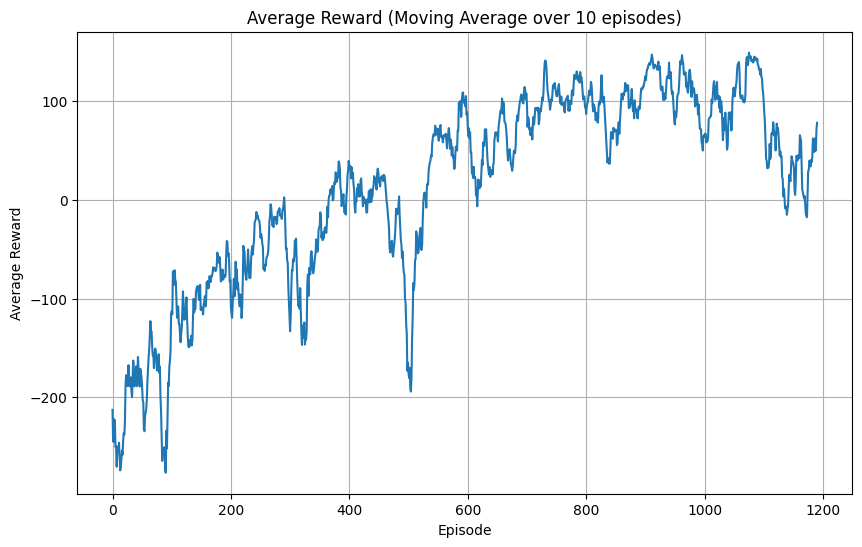

In [36]:
import matplotlib.pyplot as plt

# Compute moving average of rewards
def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Plot average reward curve
avg_rewards = moving_average(reward_history, window_size=10)

plt.figure(figsize=(10, 6))
plt.plot(avg_rewards)
plt.title("Average Reward (Moving Average over 10 episodes)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

## Testing
The testing result will be the average reward of 5 testing

In [37]:
import os
from gymnasium.wrappers import RecordVideo
import gymnasium as gym # Import gymnasium
import glob # Import glob for file listing

# Create a directory to save the videos if it doesn't exist
video_dir = "./videos"
os.makedirs(video_dir, exist_ok=True)

# Clear previous video files in the directory
for file_name in glob.glob(f'{video_dir}/*.mp4'):
    os.remove(file_name)

# Create a new environment instance for testing with rgb_array render mode
test_env_raw = gym.make('LunarLander-v3', render_mode='rgb_array')

agent.network.eval()  # set the network into evaluation mode
NUM_OF_TEST = 5 # Do not revise this !!!
test_total_reward = []
action_list = []

# Wrap the testing environment with RecordVideo
test_env = RecordVideo(test_env_raw, video_dir, episode_trigger=lambda x: x % 1 == 0) # Record every episode

for i in range(NUM_OF_TEST):
  actions = []
  state, info = test_env.reset() # Reset with seed for reproducibility

  # img = plt.imshow(test_env.render(mode='rgb_array')) # Remove this line

  total_reward = 0

  done = False
  while not done:
      # action, _ = agent.sample(state) # Use agent.sample to get log_prob and action
      # Need to get action from agent without log_prob during testing
      state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
      #log_prob, action = agent.sample(state)
      logits, _ = agent.network(state_tensor)
      action = torch.argmax(logits, dim=-1).item()

      # actions.append(action) # save the result of testing - actions is a list of integers
      actions.append(action) # Append the action as an integer

      next_state, reward, terminated, truncated, info = test_env.step(action) # Use test_env.step()
      done = terminated or truncated # Update done

      total_reward += reward
      state = next_state # Update state

      # If you don't want to see the animation, comment the next 3-line codes.
      # img.set_data(test_env.render()) # Use test_env.render()
      # display.display(plt.gcf())
      # display.clear_output(wait=True)

  print(f"Episode {i+1} Total Reward: {total_reward}")
  test_total_reward.append(total_reward)

  action_list.append(actions) # save the result of testing

# Close the wrapped environment to save the video
test_env.close()


# Rename the video files (assuming one video per episode)
import glob
video_files = sorted(glob.glob(f'{video_dir}/*.mp4'))
for i, video_file in enumerate(video_files):
    new_file_name = os.path.join(video_dir, f"trained_agent_episode_{i+1}.mp4")
    os.rename(video_file, new_file_name)


print(f"Mean Reward over {NUM_OF_TEST} episodes: {np.mean(test_total_reward)}")

Episode 1 Total Reward: 209.11169670094432
Episode 2 Total Reward: 247.32488060841135
Episode 3 Total Reward: 199.43395701969675
Episode 4 Total Reward: 275.37597048192646
Episode 5 Total Reward: 199.943815385467
Mean Reward over 5 episodes: 226.23806403928916


In [38]:
import io
import base64
from IPython.display import HTML, display
import glob
import os

video_dir = "./videos"
video_files = sorted(glob.glob(f'{video_dir}/trained_agent_episode_*.mp4'))

if len(video_files) == 0:
    print(f"No videos found in {video_dir} matching the pattern 'trained_agent_episode_*.mp4'")
else:
    for video_path in video_files:
        print(f"Displaying: {os.path.basename(video_path)}")
        try:
            with io.open(video_path, 'r+b') as f:
                encoded = base64.b64encode(f.read()).decode()
            uploaded = HTML(data='''
                <video width="320" height="240" controls>
                    <source src="data:video/mp4;base64,{}" type="video/mp4" />
                </video>'''.format(encoded))
            display(uploaded)
        except FileNotFoundError:
            print(f"Video file not found at {video_path}")

Displaying: trained_agent_episode_1.mp4


Displaying: trained_agent_episode_2.mp4


Displaying: trained_agent_episode_3.mp4


Displaying: trained_agent_episode_4.mp4


Displaying: trained_agent_episode_5.mp4
